<a href="https://colab.research.google.com/github/ClassNeuralNetwork/classification_spotify_music/blob/main/Projeto_Redes_Neurais_DataSetSpotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub[pandas-datasets]

In [44]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub
import shap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [45]:
path = kagglehub.dataset_download("solomonameh/spotify-music-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'spotify-music-dataset' dataset.
Path to dataset files: /kaggle/input/spotify-music-dataset


In [46]:
dados = pd.read_csv('/root/.cache/kagglehub/datasets/solomonameh/spotify-music-dataset/versions/1/high_popularity_spotify_data.csv')

In [47]:
colunas = [
    'track_name',
    'track_artist',
    'energy',
    'tempo',
    'danceability',
    'playlist_genre',
    'loudness',
    'valence',
    'track_popularity',
    'duration_ms'
]

dados = dados[colunas]

display(dados.head(10))

,track_name,track_artist,energy,tempo,danceability,playlist_genre,loudness,valence,track_popularity,duration_ms
0,Die With A Smile,"Lady Gaga, Bruno Mars",0.592,157.969,0.521,pop,-7.777,0.535,100,251668
1,BIRDS OF A FEATHER,Billie Eilish,0.507,104.978,0.747,pop,-10.171,0.438,97,210373
2,That’s So True,Gracie Abrams,0.808,108.548,0.554,pop,-4.169,0.372,93,166300
3,Taste,Sabrina Carpenter,0.910,112.966,0.670,pop,-4.070,0.786,81,157280
4,APT.,"ROSÉ, Bruno Mars",0.783,149.027,0.777,pop,-4.477,0.939,98,169917
5,"Good Luck, Babe!",Chappell Roan,0.582,116.712,0.700,pop,-5.960,0.785,94,218424
6,Diet Pepsi,Addison Rae,0.561,150.069,0.669,pop,-6.538,0.841,88,169698
7,WILDFLOWER,Billie Eilish,0.247,148.101,0.467,pop,-12.002,0.126,93,261467
8,Sailor Song,Gigi Perez,0.416,94.926,0.492,pop,-10.439,0.297,71,211979
9,Timeless (with Playboi Carti),"The Weeknd, Playboi Carti",0.722,119.973,0.769,pop,-5.485,0.570,92,256000


In [48]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_name        1686 non-null   object 
 1   track_artist      1686 non-null   object 
 2   energy            1686 non-null   float64
 3   tempo             1686 non-null   float64
 4   danceability      1686 non-null   float64
 5   playlist_genre    1686 non-null   object 
 6   loudness          1686 non-null   float64
 7   valence           1686 non-null   float64
 8   track_popularity  1686 non-null   int64  
 9   duration_ms       1686 non-null   int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 131.8+ KB


In [49]:
entrada = dados.drop('playlist_genre', axis=1)
saida = dados['playlist_genre']

In [80]:
entrada_treino, entrada_teste, saida_treino, saida_teste = train_test_split(entrada, saida, test_size=0.2, random_state=42)

In [81]:
#Foi adicionada para poder ler as colunas que contêm texto, já que ele não consegue fazer calculos nas colunas q tem texto

colunas_numericas = entrada_treino.select_dtypes(include=['float64', 'int64']).columns

padronizador = StandardScaler()
entrada_treino[colunas_numericas] = padronizador.fit_transform(entrada_treino[colunas_numericas])
entrada_teste[colunas_numericas] = padronizador.transform(entrada_teste[colunas_numericas])

In [82]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

In [83]:
X_treino = entrada_treino[colunas_numericas]
X_teste = entrada_teste[colunas_numericas]

#Transformar os textos em números
label_encoder = LabelEncoder()
y_treino = label_encoder.fit_transform(saida_treino)
y_teste = label_encoder.transform(saida_teste)

modelo_sp = Sequential([
    Dense(64, activation='relu', input_shape=(X_treino.shape[1],)),
    Dense(32, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')
])

modelo_sp.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

historico = modelo_sp.fit(X_treino, y_treino, epochs = 80, batch_size=32, validation_data=(X_teste, y_teste))

Epoch 1/80


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1304 - val_loss: 2.8465
Epoch 2/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6111 - val_loss: 2.4214
Epoch 3/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3438 - val_loss: 2.2611
Epoch 4/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2218 - val_loss: 2.1734
Epoch 5/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1363 - val_loss: 2.1131
Epoch 6/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0755 - val_loss: 2.0698
Epoch 7/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0273 - val_loss: 2.0287
Epoch 8/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9916 - val_loss: 1.9984
Epoch 9/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9571 - val_loss: 1.9742
Epoch 10/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9353 - val_loss: 1.9590
Epoch 11/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9111 - val_loss: 1.9426
Epoch 12/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8897 - val_loss: 1.9218


In [84]:
modelo_sp.save('Spotify_Classification.keras')

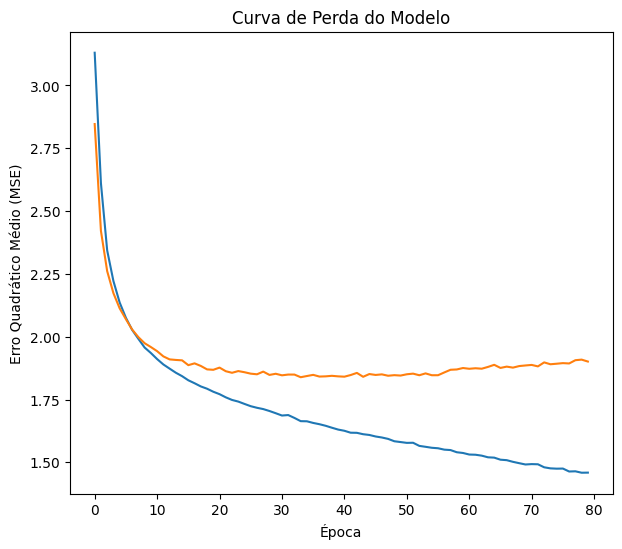

In [85]:
plt.figure(figsize=(7, 6))
plt.plot(historico.history['loss'])
plt.plot(historico.history['val_loss'])
plt.title('Curva de Perda do Modelo')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.xlabel('Época')
plt.show()

In [87]:
previsoes_prob = modelo_sp.predict(X_teste)

classes_preditas = np.argmax(previsoes_prob, axis=1)
classes_reais =  y_teste

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [91]:
print(classification_report(classes_reais, classes_preditas, labels=range(len(label_encoder.classes_)), target_names=label_encoder.classes_, zero_division=0))

              precision    recall  f1-score   support

   afrobeats       0.00      0.00      0.00         5
     ambient       0.22      0.40      0.29         5
      arabic       0.00      0.00      0.00        10
       blues       0.50      0.14      0.22        14
   brazilian       0.00      0.00      0.00         3
   classical       0.67      0.50      0.57         4
     country       0.00      0.00      0.00         1
  electronic       0.63      0.33      0.44        36
        folk       0.00      0.00      0.00         2
      gaming       0.56      0.38      0.45        26
     hip-hop       0.40      0.53      0.46        43
      indian       0.00      0.00      0.00         1
       indie       0.00      0.00      0.00         2
       j-pop       0.00      0.00      0.00         2
        jazz       0.00      0.00      0.00         0
       k-pop       0.00      0.00      0.00         1
      korean       1.00      0.33      0.50         3
       latin       0.31    

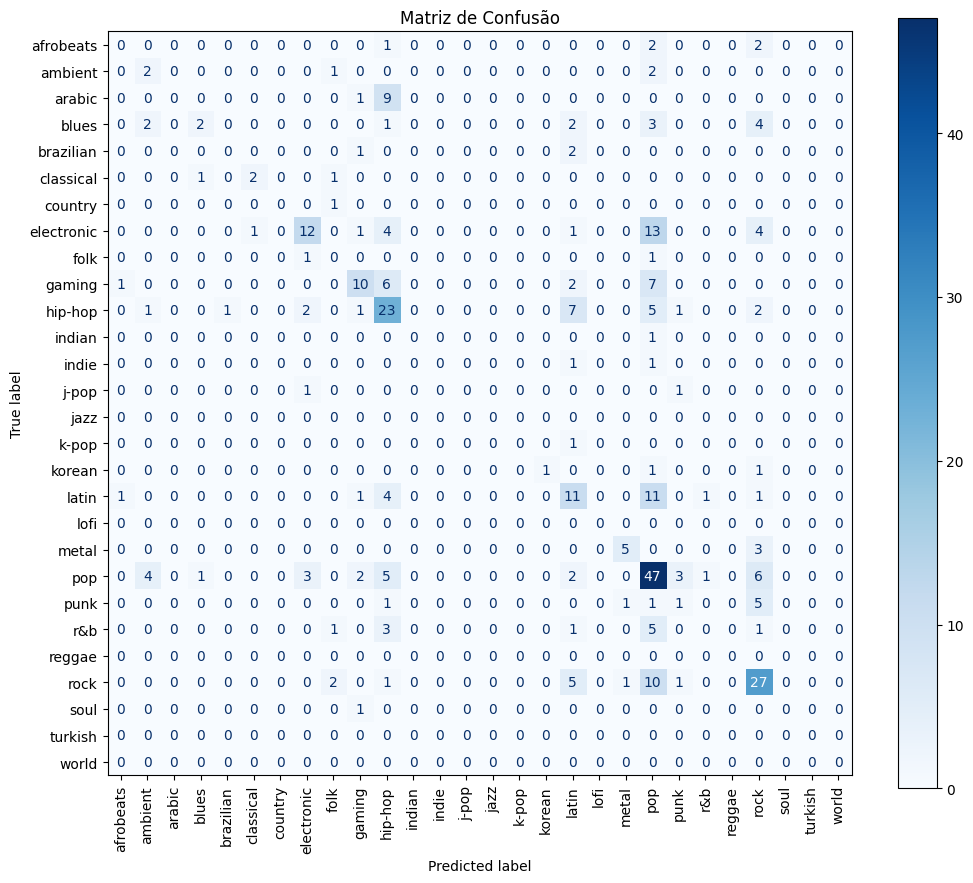

In [93]:
matriz_confusao = confusion_matrix(classes_reais, classes_preditas, labels=range(len(label_encoder.classes_)))

fig, ax = plt.subplots(figsize=(12, 10))
display_matriz = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=label_encoder.classes_)
display_matriz.plot(cmap=plt.cm.Blues, values_format='d', ax=ax, xticks_rotation='vertical')
plt.title('Matriz de Confusão')
plt.show()

In [94]:
explainer = shap.KernelExplainer(modelo_sp.predict, X_teste[:50])
shap_values = explainer.shap_values(X_teste)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


  0%|          | 0/338 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
197/197 ━━━━━━

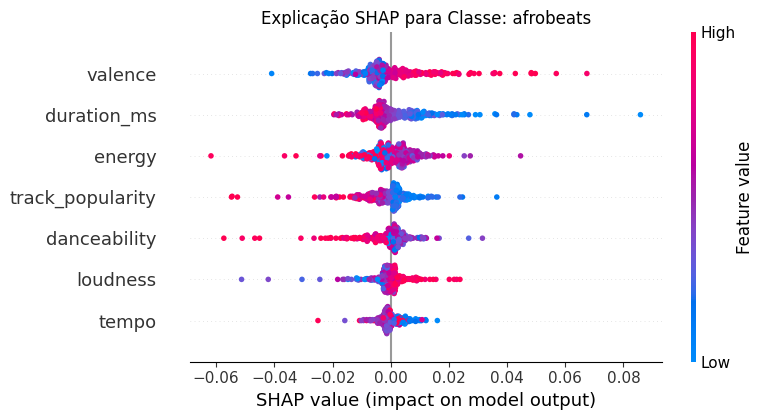

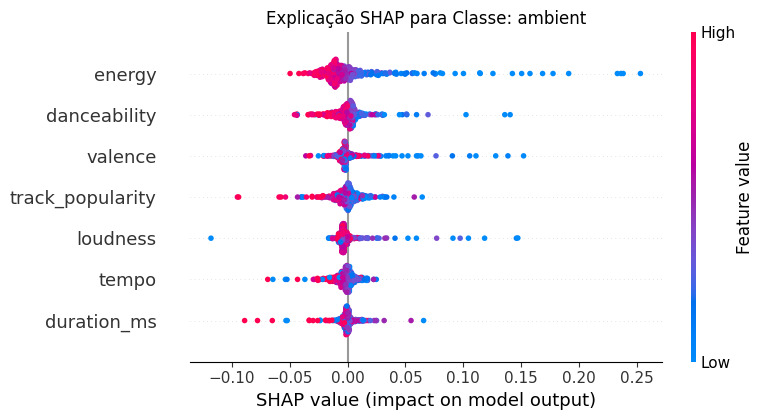

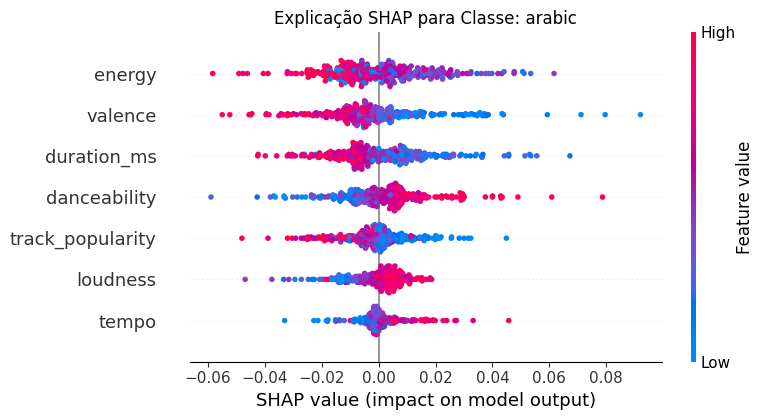

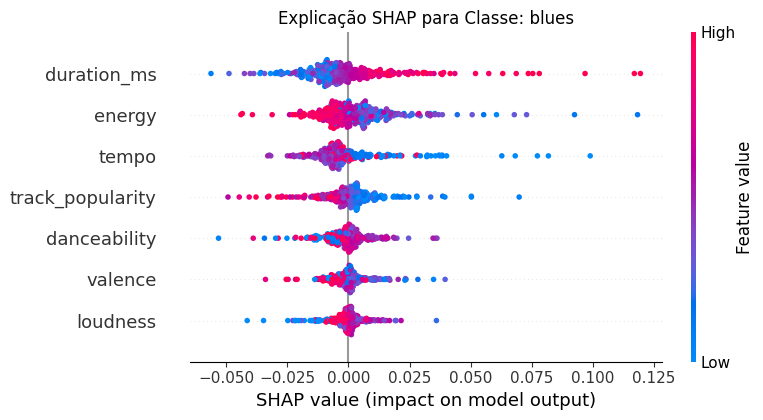

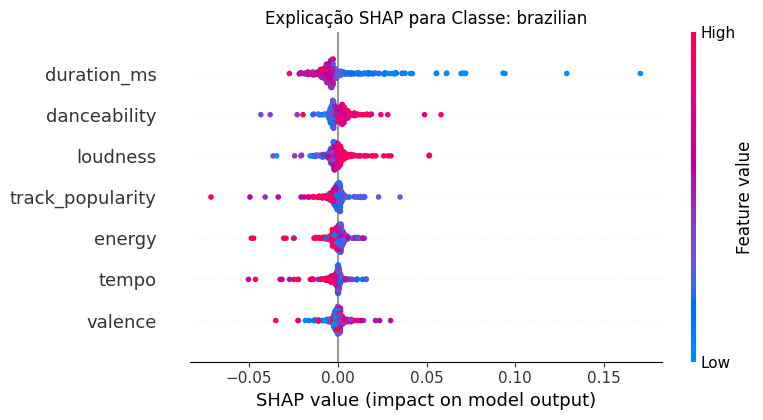

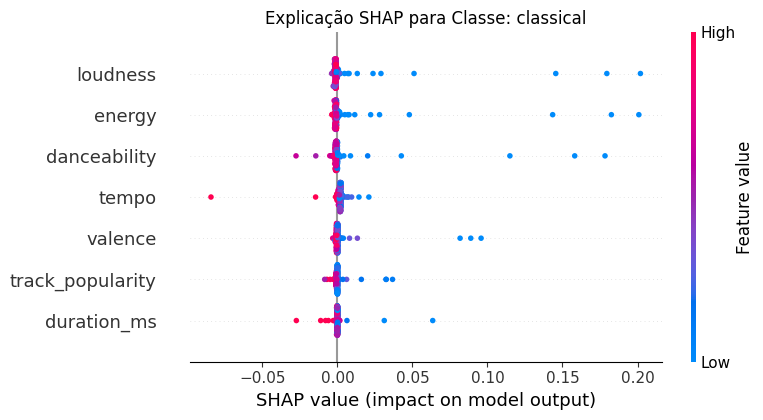

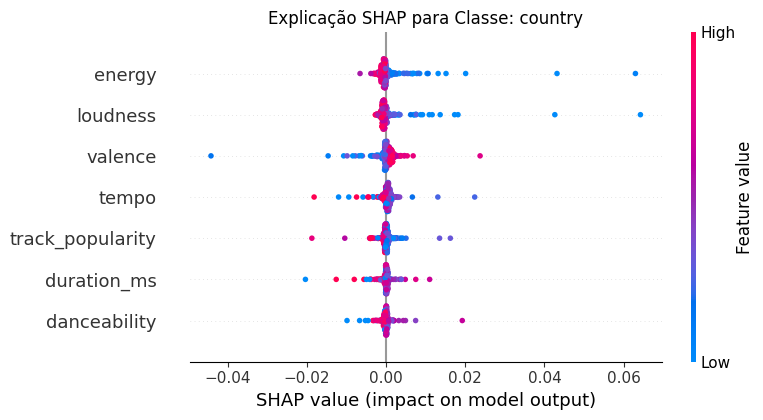

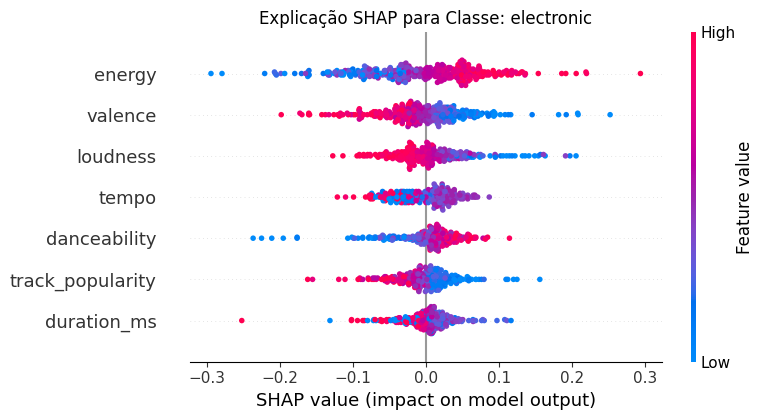

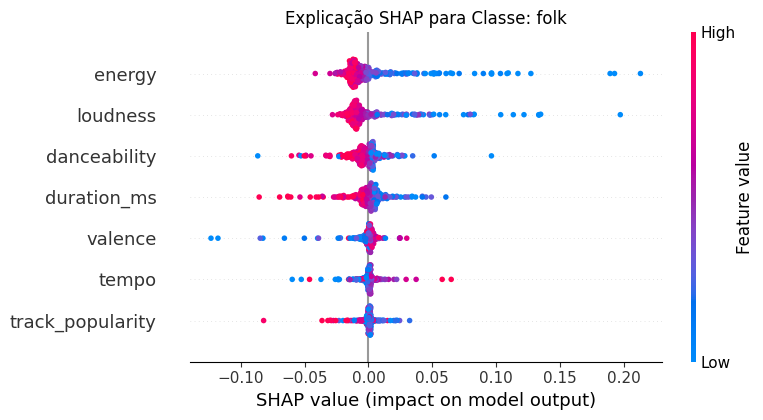

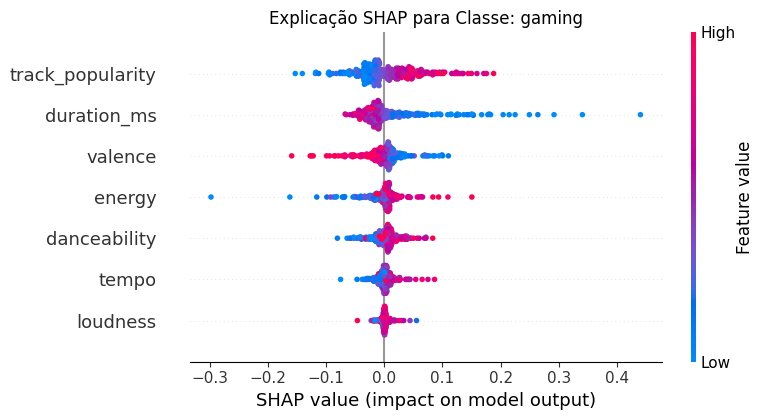

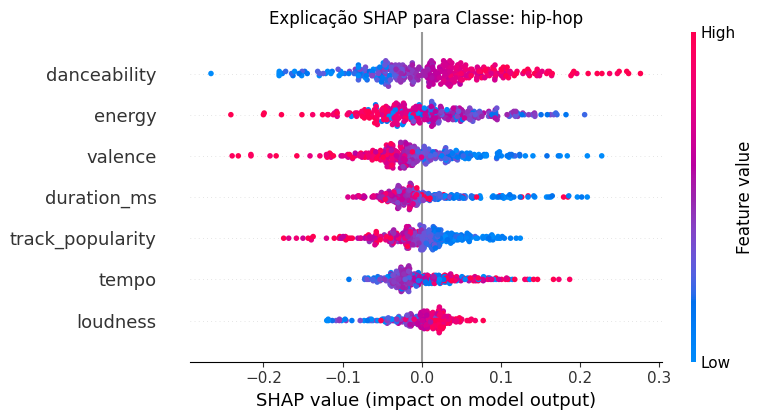

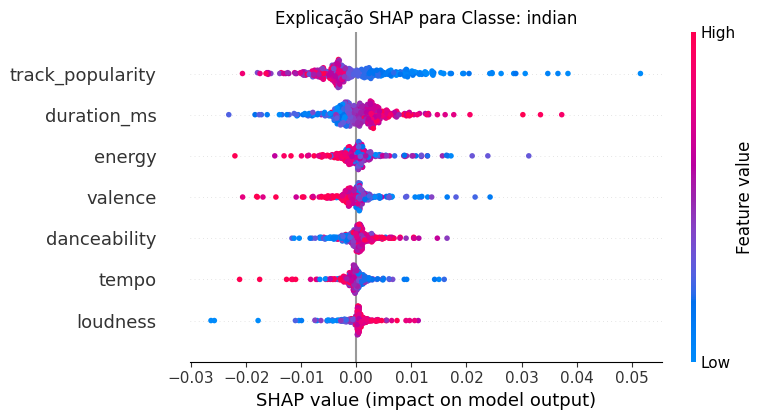

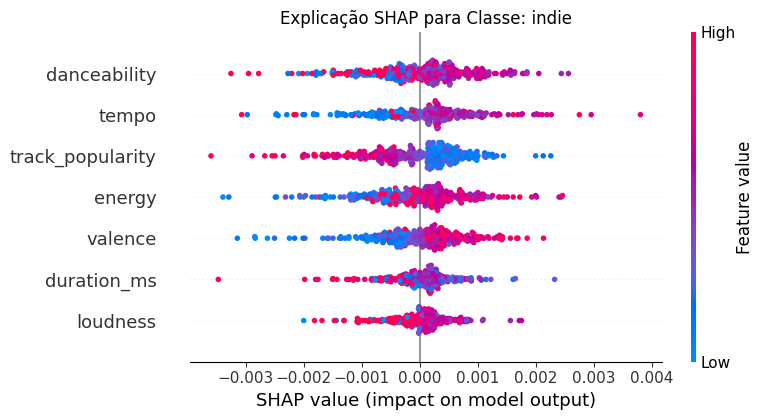

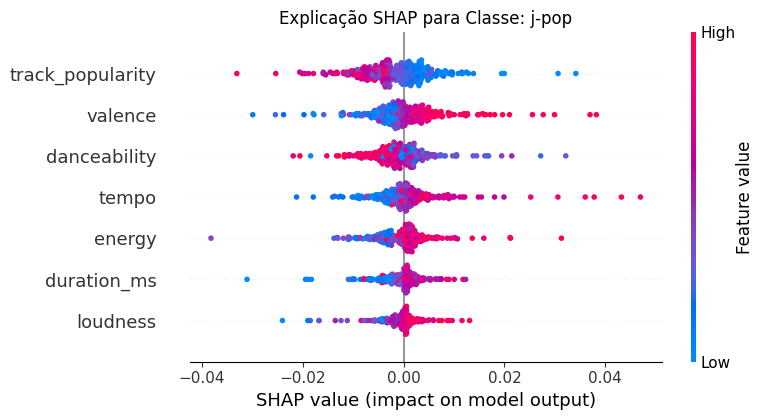

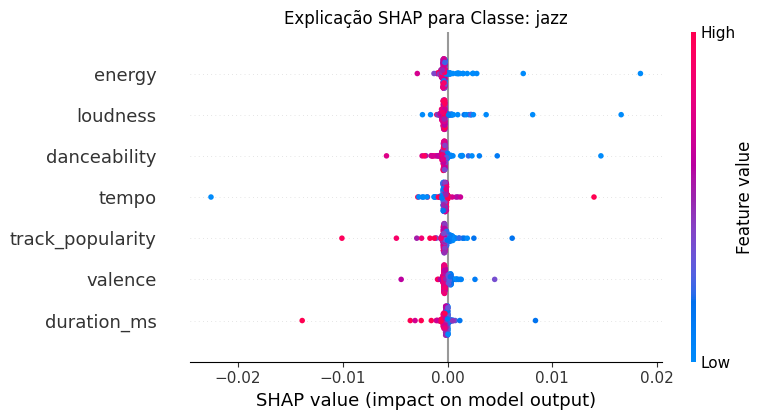

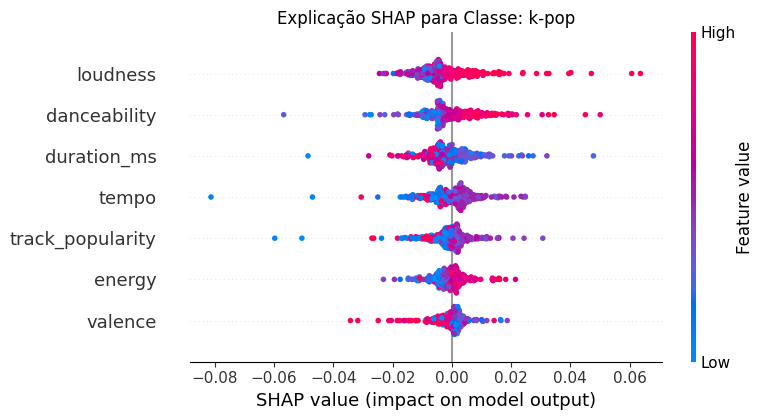

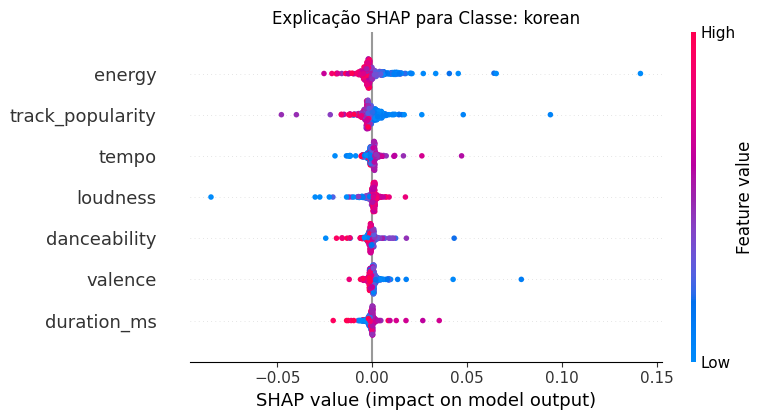

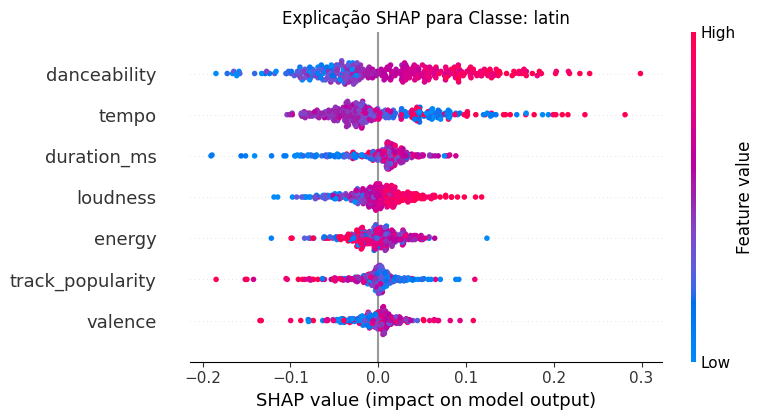

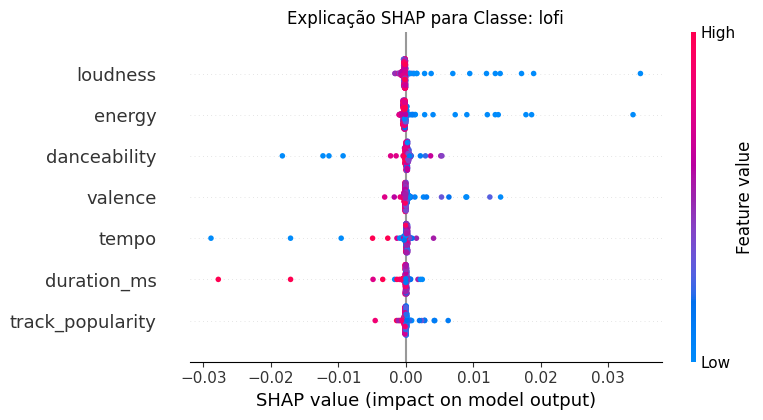

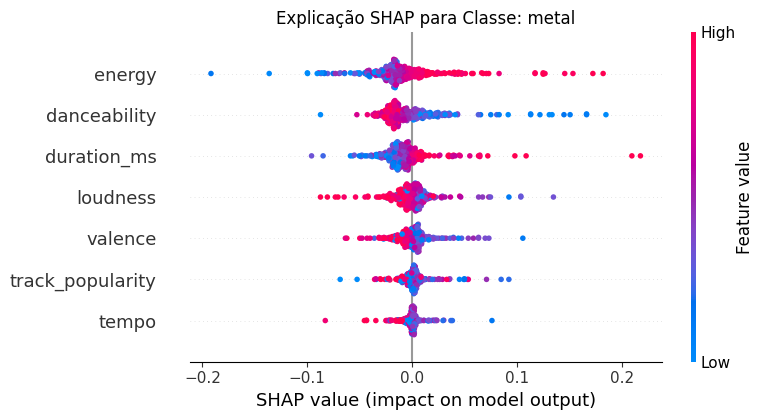

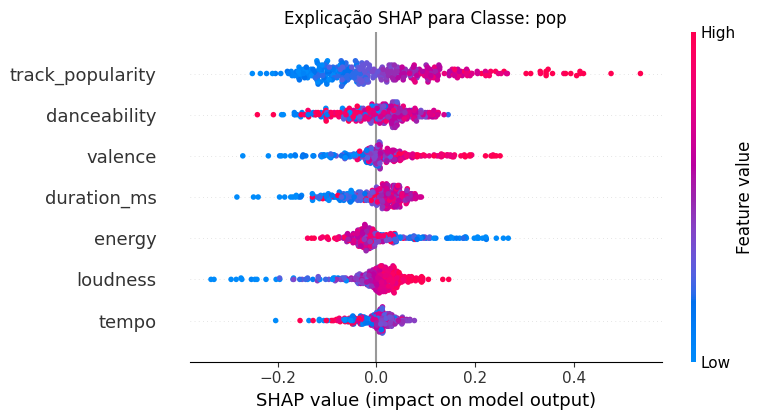

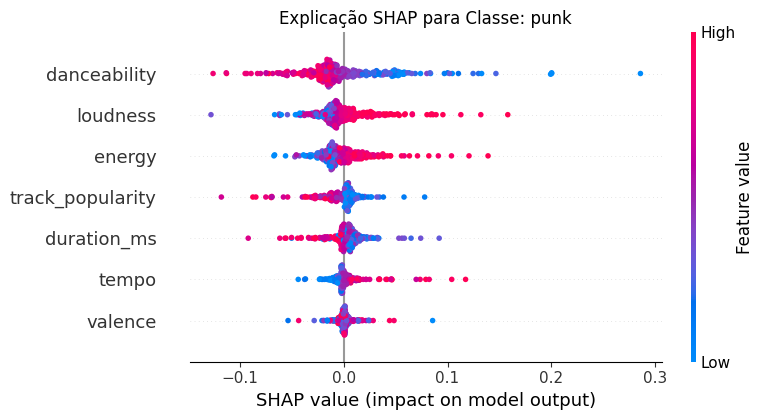

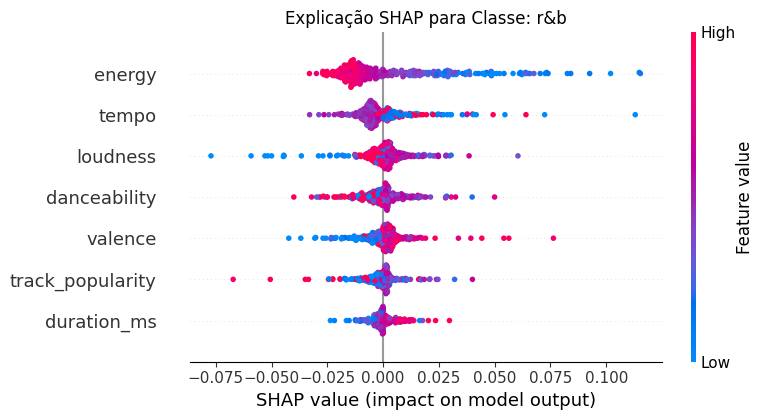

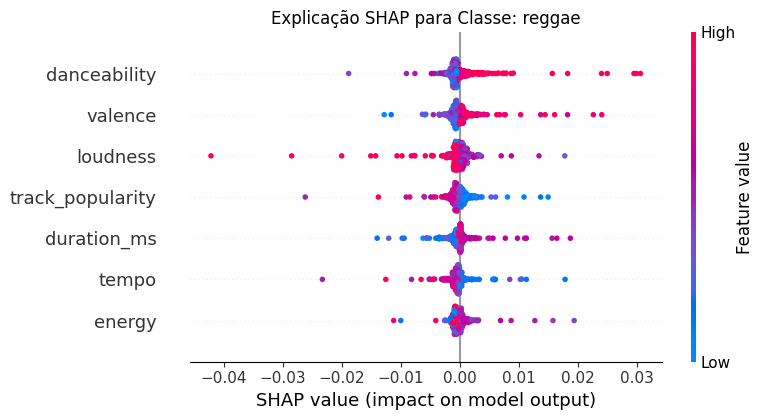

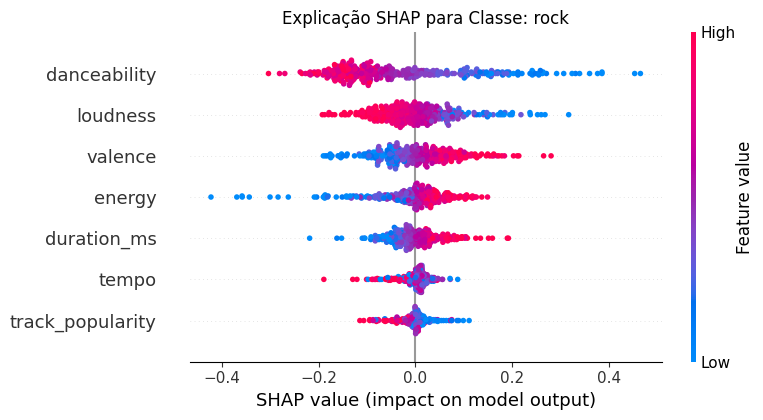

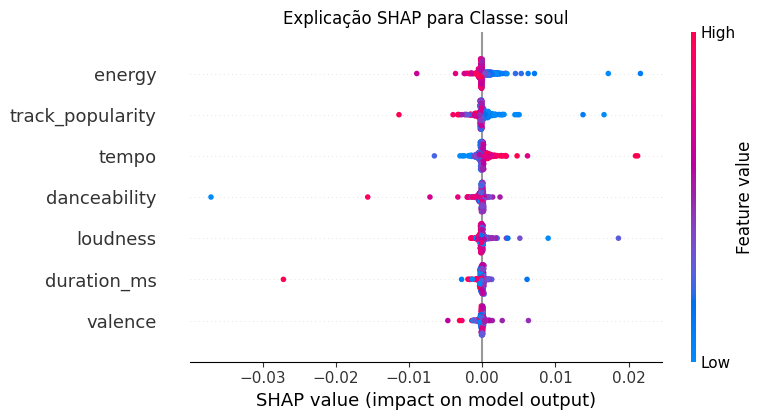

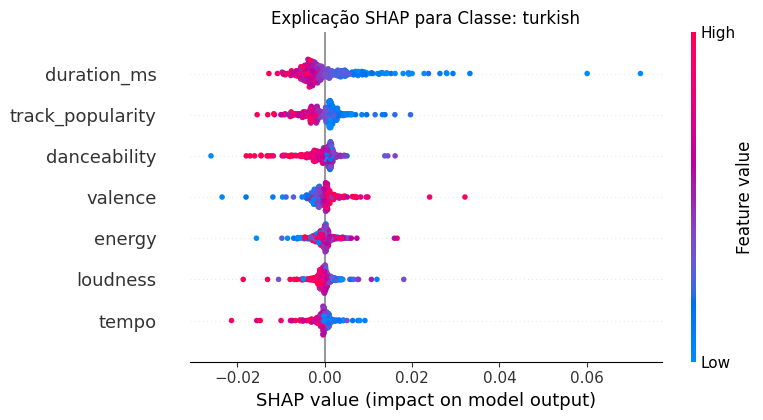

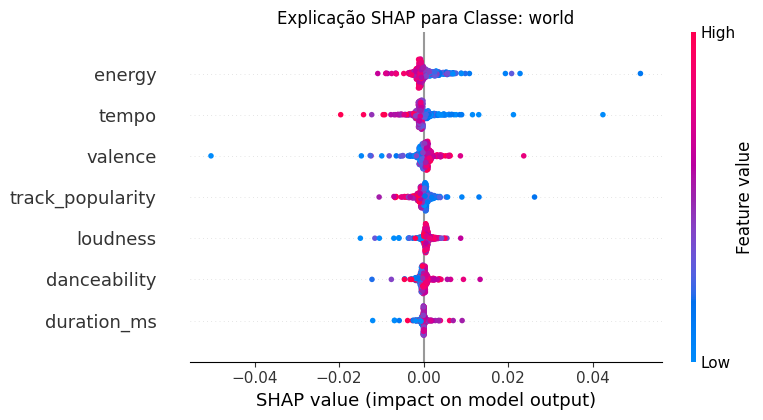

In [95]:
class_names = list(label_encoder.classes_)

for i, class_name in enumerate(class_names):
  plt.figure(figsize=(6, 3))
  plt.title(f"Explicação SHAP para Classe: {class_name}")
  shap_val_class = shap_values[:, :, i]

  shap.summary_plot(shap_val_class, X_teste, feature_names=list(colunas_numericas))
  plt.show()